In [9]:
import os

aug_folder = r"C:\Users\Aishwarya\Downloads\POACHING_PROJECT\dataset\augmented_gunshots"
print("Augmented files:", len(os.listdir(aug_folder)))

Augmented files: 1362


In [10]:
import os
import shutil

aug_folder = r"C:\Users\Aishwarya\Downloads\POACHING_PROJECT\dataset\augmented_gunshots"
train_gun_folder = r"C:\Users\Aishwarya\Downloads\POACHING_PROJECT\dataset\gunshot_binary_dataset\train\gunshot"

files = os.listdir(aug_folder)

for f in files:
    shutil.move(os.path.join(aug_folder, f),
                os.path.join(train_gun_folder, f))

print("Moved augmented files successfully.")

Moved augmented files successfully.


In [65]:
import os

base_path = r"C:\Users\Aishwarya\Downloads\POACHING_PROJECT\dataset\gunshot_binary_dataset"

print("=== TOP LEVEL ===")
for item in os.listdir(base_path):
    print(item)

print("\n=== FULL STRUCTURE ===")

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files[:5]:  # show first 5 files per folder
        print(f"{subindent}{f}")

=== TOP LEVEL ===
train
val

=== FULL STRUCTURE ===
gunshot_binary_dataset/
    train/
        ambient/
            1-101296-A-19.wav
            1-101296-B-19.wav
            1-101336-A-30.wav
            1-103995-A-30.wav
            1-103999-A-30.wav
        gunshot/
            1 (1).wav
            1 (11).wav
            1 (13).wav
            1 (14).wav
            1 (16).wav
    val/
        ambient/
            10_11001.wav
            10_11002.wav
            10_11015.wav
            10_11021.wav
            10_11025.wav
        gunshot/
            1 (10).wav
            1 (12).wav
            1 (15).wav
            1 (18).wav
            1 (24).wav


In [66]:
import os

base_path = r"C:\Users\Aishwarya\Downloads\POACHING_PROJECT\dataset\gunshot_binary_dataset"

for split in ["train", "val"]:
    print(f"\n=== {split.upper()} ===")
    split_path = os.path.join(base_path, split)
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            print(cls, ":", len(os.listdir(cls_path)))


=== TRAIN ===
ambient : 2020
gunshot : 2043

=== VAL ===
ambient : 405
gunshot : 170


In [67]:
import numpy as np
import random
import librosa
from scipy.signal import butter, lfilter

def lowpass_filter(y, sr, cutoff=3000):
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(4, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, y)

def simulate_suppressed_shot(y, sr):
    # Reduce gain (distance simulation)
    y = y * random.uniform(0.2, 0.6)

    # Low-pass filter (suppressor simulation)
    y = lowpass_filter(y, sr, cutoff=random.uniform(2000, 4000))

    # Add light echo (forest reflection)
    delay = int(0.02 * sr)
    echo = np.zeros_like(y)
    echo[delay:] = y[:-delay] * 0.3
    y = y + echo

    # Normalize
    y = y / (np.max(np.abs(y)) + 1e-6)

    return y
    

In [68]:
def extract_features(path):
    y, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)

    if len(y) > SAMPLES:
        y = y[:SAMPLES]
    else:
        y = np.pad(y, (0, SAMPLES - len(y)))

    # Randomly simulate suppressed version (ONLY for gunshot class later)
    return y

In [69]:
def build_dataset(base_path):
    X = []
    y_labels = []

    for label, class_name in enumerate(["ambient", "gunshot"]):
        class_path = os.path.join(base_path, class_name)

        for file in os.listdir(class_path):
            if not file.endswith(".wav"):
                continue

            path = os.path.join(class_path, file)

            y_audio, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)

            if len(y_audio) > SAMPLES:
                y_audio = y_audio[:SAMPLES]
            else:
                y_audio = np.pad(y_audio, (0, SAMPLES - len(y_audio)))

            # If gunshot, sometimes simulate suppressed
            if class_name == "gunshot" and random.random() < 0.4:
                y_audio = simulate_suppressed_shot(y_audio, sr)

            # ---- Feature extraction ----
            mel = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=64)
            log_mel = librosa.power_to_db(mel, ref=np.max)

            delta = librosa.feature.delta(log_mel)
            delta2 = librosa.feature.delta(log_mel, order=2)

            rms = librosa.feature.rms(y=y_audio)
            zcr = librosa.feature.zero_crossing_rate(y_audio)
            centroid = librosa.feature.spectral_centroid(y=y_audio, sr=sr)
            rolloff = librosa.feature.spectral_rolloff(y=y_audio, sr=sr)

            # Resize physics features to match mel time frames
            target_frames = log_mel.shape[1]

            def resize_feature(feat):
                return np.resize(feat, (1, target_frames))

            rms = resize_feature(rms)
            zcr = resize_feature(zcr)
            centroid = resize_feature(centroid)
            rolloff = resize_feature(rolloff)

            # Stack channels
            features = np.stack([
                log_mel,
                delta,
                delta2,
                rms,
                zcr,
                centroid,
                rolloff
            ], axis=-1)

            X.append(features)
            y_labels.append(label)

    return np.array(X), np.array(y_labels)

In [70]:
layers.Input(shape=X_train.shape[1:])
model.save("gunshot_model_v2.h5")
np.save("train_mean_v2.npy", train_mean)
np.save("train_std_v2.npy", train_std)

In [71]:
import os
import random
import numpy as np
import librosa
import tensorflow as tf
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models
from scipy.signal import butter, lfilter

SAMPLE_RATE = 22050
DURATION = 2
SAMPLES = SAMPLE_RATE * DURATION
N_MELS = 64

BASE_PATH = r"C:\Users\Aishwarya\Downloads\POACHING_PROJECT\dataset\gunshot_binary_dataset"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH = os.path.join(BASE_PATH, "val")

In [72]:
def lowpass_filter(y, sr, cutoff=3000):
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(4, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, y)

def simulate_suppressed_shot(y, sr):
    y = y * random.uniform(0.2, 0.6)
    y = lowpass_filter(y, sr, cutoff=random.uniform(2000, 4000))

    delay = int(0.02 * sr)
    echo = np.zeros_like(y)
    echo[delay:] = y[:-delay] * 0.3
    y = y + echo

    y = y / (np.max(np.abs(y)) + 1e-6)
    return y

In [76]:
def build_dataset(base_path):
    X = []
    y_labels = []

    for label, class_name in enumerate(["ambient", "gunshot"]):
        class_path = os.path.join(base_path, class_name)

        for file in tqdm(os.listdir(class_path)):
            if not file.endswith(".wav"):
                continue

            path = os.path.join(class_path, file)

            # Load audio
            y_audio, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)

            # Pad or trim to fixed length
            if len(y_audio) > SAMPLES:
                y_audio = y_audio[:SAMPLES]
            else:
                y_audio = np.pad(y_audio, (0, SAMPLES - len(y_audio)))

            # Apply suppressor simulation for some gunshots
            if class_name == "gunshot" and random.random() < 0.4:
                y_audio = simulate_suppressed_shot(y_audio, sr)

            # ----------- Spectral Features -----------
            mel = librosa.feature.melspectrogram(
                y=y_audio,
                sr=sr,
                n_mels=N_MELS
            )

            log_mel = librosa.power_to_db(mel, ref=np.max)
            delta = librosa.feature.delta(log_mel)
            delta2 = librosa.feature.delta(log_mel, order=2)

            # ----------- Physics Features -----------
            rms = librosa.feature.rms(y=y_audio)
            zcr = librosa.feature.zero_crossing_rate(y_audio)
            centroid = librosa.feature.spectral_centroid(y=y_audio, sr=sr)
            rolloff = librosa.feature.spectral_rolloff(y=y_audio, sr=sr)

            # Ensure time dimension matches mel spectrogram
            target_frames = log_mel.shape[1]

            def match_time_and_expand(feat):
                # Resize time axis
                if feat.shape[1] != target_frames:
                    feat = np.resize(feat, (1, target_frames))

                # Repeat across frequency axis (64 mel bins)
                feat = np.repeat(feat, N_MELS, axis=0)
                return feat

            rms = match_time_and_expand(rms)
            zcr = match_time_and_expand(zcr)
            centroid = match_time_and_expand(centroid)
            rolloff = match_time_and_expand(rolloff)

            # ----------- Stack All Features -----------
            features = np.stack([
                log_mel,
                delta,
                delta2,
                rms,
                zcr,
                centroid,
                rolloff
            ], axis=-1)

            X.append(features)
            y_labels.append(label)

    return np.array(X), np.array(y_labels)

In [77]:
X_train, y_train = build_dataset(TRAIN_PATH)
X_val, y_val = build_dataset(VAL_PATH)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
train_mean = np.mean(X_train)
train_std = np.std(X_train)

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std


100%|████████████████████████████████████████████████████████████████████████████████| 170/170 [00:09<00:00, 18.34it/s]


Train shape: (4063, 64, 87, 7)
Val shape: (575, 64, 87, 7)


In [78]:
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 62, 85, 32)          │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 31, 42, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 29, 40, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 14, 20, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 17920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │       2,293,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,314,561 (8.83 MB)

 Trainable params: 2,314,561 (8.83 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.5882 - loss: 0.8963 - val_accuracy: 0.4870 - val_loss: 0.5987
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.6468 - loss: 0.5792 - val_accuracy: 0.5409 - val_loss: 0.5765
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.6779 - loss: 0.5501 - val_accuracy: 0.5670 - val_loss: 0.5289
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.6962 - loss: 0.5244 - val_accuracy: 0.5878 - val_loss: 0.5244
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.7212 - loss: 0.5064 - val_accuracy: 0.7983 - val_loss: 0.4315
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.7472 - loss: 0.4619 - val_accuracy: 0.7252 - val_loss: 0.5053
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.7939 - loss: 0.4236 - val_accuracy: 0.8278 - val_loss: 0.3970
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.8170 - loss: 0.3983 - val_acc

In [80]:
loss, acc = model.evaluate(X_val, y_val)
print(f"\nValidation Accuracy: {acc:.4f}")

y_pred = model.predict(X_val)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8434 - loss: 0.4895

Validation Accuracy: 0.8470
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
[[349  56]
 [ 32 138]]
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       405
           1       0.71      0.81      0.76       170

    accuracy                           0.85       575
   macro avg       0.81      0.84      0.82       575
weighted avg       0.86      0.85      0.85       575



In [81]:
model.save("gunshot_model_v2.h5")
np.save("train_mean_v2.npy", train_mean)
np.save("train_std_v2.npy", train_std)

print("Model saved.")

Model saved.


In [84]:
def test_sample(audio_path):
    y_audio, sr = librosa.load(audio_path, sr=SAMPLE_RATE, mono=True)

    if len(y_audio) > SAMPLES:
        y_audio = y_audio[:SAMPLES]
    else:
        y_audio = np.pad(y_audio, (0, SAMPLES - len(y_audio)))

    # -------- Spectral features --------
    mel = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=N_MELS)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    delta = librosa.feature.delta(log_mel)
    delta2 = librosa.feature.delta(log_mel, order=2)

    # -------- Physics features --------
    rms = librosa.feature.rms(y=y_audio)
    zcr = librosa.feature.zero_crossing_rate(y_audio)
    centroid = librosa.feature.spectral_centroid(y=y_audio, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y_audio, sr=sr)

    target_frames = log_mel.shape[1]

    def match_time_and_expand(feat):
        if feat.shape[1] != target_frames:
            feat = np.resize(feat, (1, target_frames))
        return np.repeat(feat, N_MELS, axis=0)

    rms = match_time_and_expand(rms)
    zcr = match_time_and_expand(zcr)
    centroid = match_time_and_expand(centroid)
    rolloff = match_time_and_expand(rolloff)

    features = np.stack([
        log_mel,
        delta,
        delta2,
        rms,
        zcr,
        centroid,
        rolloff
    ], axis=-1)

    # Normalize using SAME training stats
    features = (features - train_mean) / train_std
    features = features[np.newaxis, ...]

    prob = model.predict(features, verbose=0)[0][0]

    print("Probability:", round(float(prob), 4))

    if prob > 0.5:
        print("🔥 GUNSHOT")
    else:
        print("🌿 AMBIENT")

In [85]:
model = tf.keras.models.load_model("gunshot_model_v2.h5")
train_mean = np.load("train_mean_v2.npy")
train_std = np.load("train_std_v2.npy")

In [86]:
test_sample(r"C:\Users\Aishwarya\Downloads\POACHING_PROJECT\dataset\gunshot_binary_dataset\val\gunshot\5 (69).wav")

Probability: 0.5843
🔥 GUNSHOT


In [87]:
test_sample(r"C:\Users\Aishwarya\Downloads\POACHING_PROJECT\dataset\gunshot_binary_dataset\val\gunshot\5 (65).wav")

Probability: 0.9997
🔥 GUNSHOT


In [90]:
test_sample(r"C:\Users\Aishwarya\Downloads\archive (4)\ESC-50-master\audio\5-243459-A-14.wav")

Probability: 0.0083
🌿 AMBIENT


In [91]:
test_sample(r"C:\Users\Aishwarya\Downloads\archive (4)\ESC-50-master\audio\5-213836-C-9.wav")

Probability: 0.1429
🌿 AMBIENT


In [92]:
test_sample(r"C:\Users\Aishwarya\Downloads\archive (4)\ESC-50-master\audio\3-128160-A-44.wav")

Probability: 0.4187
🌿 AMBIENT


In [93]:
test_sample(r"C:\Users\Aishwarya\Downloads\archive (4)\ESC-50-master\audio\5-156999-A-19.wav")

Probability: 0.0072
🌿 AMBIENT


In [94]:
y_probs = model.predict(X_val).flatten()
y_preds = (y_probs > 0.5).astype(int)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [95]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val, y_preds)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_val, y_preds))

Confusion Matrix:
 [[349  56]
 [ 32 138]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       405
           1       0.71      0.81      0.76       170

    accuracy                           0.85       575
   macro avg       0.81      0.84      0.82       575
weighted avg       0.86      0.85      0.85       575



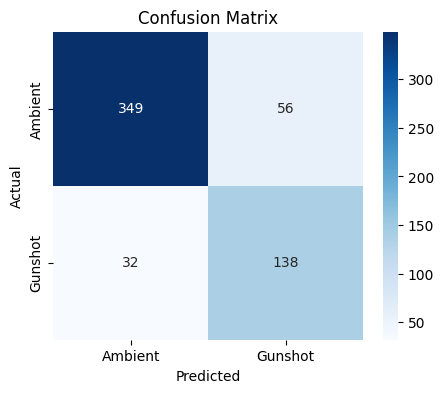

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Ambient", "Gunshot"],
            yticklabels=["Ambient", "Gunshot"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

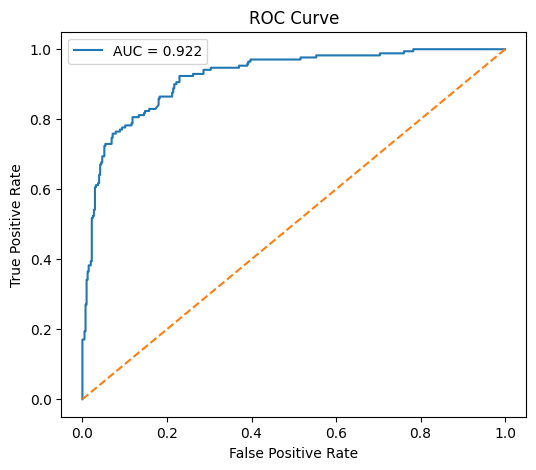

AUC: 0.9220334059549745


In [98]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_val, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC:", roc_auc)

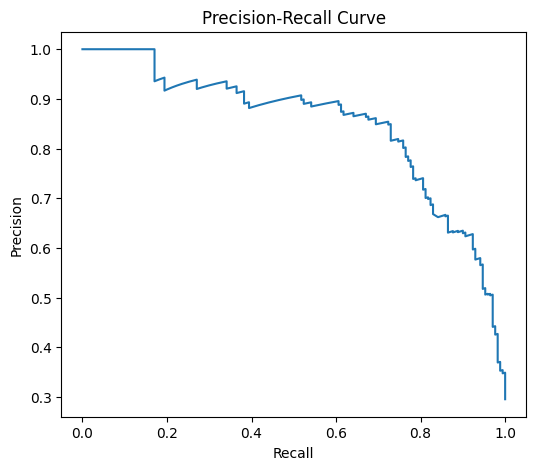

In [99]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [100]:
import numpy as np
from sklearn.metrics import f1_score

best_thresh = 0
best_f1 = 0

for t in np.arange(0.1, 0.9, 0.01):
    preds = (y_probs > t).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1 Score:", best_f1)

Best Threshold: 0.7499999999999997
Best F1 Score: 0.7865853658536586


In [121]:
from sklearn.metrics import confusion_matrix, classification_report

threshold = 0.4
y_preds_custom = (y_probs > threshold).astype(int)

print("Threshold =", threshold)
print(confusion_matrix(y_val, y_preds_custom))
print(classification_report(y_val, y_preds_custom))

Threshold = 0.4
[[332  73]
 [ 25 145]]
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       405
           1       0.67      0.85      0.75       170

    accuracy                           0.83       575
   macro avg       0.80      0.84      0.81       575
weighted avg       0.85      0.83      0.83       575



In [102]:
missed_indices = np.where((y_val == 1) & (y_preds == 0))[0]

print("Missed gunshot files count:", len(missed_indices))

Missed gunshot files count: 32


In [122]:
import os
import random
import numpy as np
import librosa
import tensorflow as tf
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from scipy.signal import butter, lfilter
import matplotlib.pyplot as plt

# ---------------------
# Audio Parameters
# ---------------------
SAMPLE_RATE = 22050
DURATION = 2
SAMPLES = SAMPLE_RATE * DURATION
N_MELS = 64

BASE_PATH = r"C:\Users\Aishwarya\Downloads\POACHING_PROJECT\dataset\gunshot_binary_dataset"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH   = os.path.join(BASE_PATH, "val")
TEST_PATH  = os.path.join(BASE_PATH, "test")  # create test folder if not exists

In [123]:
def lowpass_filter(y, sr, cutoff=3000):
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(4, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, y)

def simulate_suppressed_shot(y, sr):
    y = y * random.uniform(0.3, 0.6)
    y = lowpass_filter(y, sr, cutoff=random.uniform(2000, 4000))

    delay = int(0.02 * sr)
    echo = np.zeros_like(y)
    echo[delay:] = y[:-delay] * 0.3
    y = y + echo

    y = y / (np.max(np.abs(y)) + 1e-6)
    return y

In [124]:
def extract_features(path, class_name):
    y_audio, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)

    if len(y_audio) > SAMPLES:
        y_audio = y_audio[:SAMPLES]
    else:
        y_audio = np.pad(y_audio, (0, SAMPLES - len(y_audio)))

    if class_name == "gunshot" and random.random() < 0.4:
        y_audio = simulate_suppressed_shot(y_audio, sr)

    mel = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=N_MELS)
    log_mel = librosa.power_to_db(mel, ref=np.max)

    delta = librosa.feature.delta(log_mel)
    delta2 = librosa.feature.delta(log_mel, order=2)

    # Stack channels
    features = np.stack([log_mel, delta, delta2], axis=-1)

    return features

In [125]:
def build_dataset(base_path):
    X = []
    y_labels = []

    for label, class_name in enumerate(["ambient", "gunshot"]):
        class_path = os.path.join(base_path, class_name)

        for file in tqdm(os.listdir(class_path)):
            if not file.endswith(".wav"):
                continue

            path = os.path.join(class_path, file)
            features = extract_features(path, class_name)

            X.append(features)
            y_labels.append(label)

    return np.array(X), np.array(y_labels)
    

In [127]:
X_train, y_train = build_dataset(TRAIN_PATH)
X_val, y_val     = build_dataset(VAL_PATH)
X_test, y_test   = build_dataset(TEST_PATH)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)
train_mean = np.mean(X_train)
train_std  = np.std(X_train)

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

np.save("train_mean.npy", train_mean)
np.save("train_std.npy", train_std)
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1 - epsilon)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        return -tf.reduce_mean(alpha * tf.pow(1 - pt, gamma) * tf.math.log(pt))
    return loss

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 18.09it/s]


Train: (4063, 64, 87, 3)
Val: (807, 64, 87, 3)
Test: (30, 64, 87, 3)


In [128]:
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=focal_loss(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 64, 87, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 64, 87, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 64, 87, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 32, 43, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 43, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 32, 43, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 32, 43, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 16, 21, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 16, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 16, 21, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_2 (ReLU)                       │ (None, 16, 21, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 8, 10, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [129]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 51s 313ms/step - accuracy: 0.7228 - loss: 0.0375 - val_accuracy: 0.5019 - val_loss: 0.0554
Epoch 2/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 38s 296ms/step - accuracy: 0.8786 - loss: 0.0195 - val_accuracy: 0.5019 - val_loss: 0.0899
Epoch 3/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 38s 297ms/step - accuracy: 0.9081 - loss: 0.0153 - val_accuracy: 0.5626 - val_loss: 0.0592
Epoch 4/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 37s 288ms/step - accuracy: 0.9215 - loss: 0.0130 - val_accuracy: 0.8823 - val_loss: 0.0174
Epoch 5/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 38s 295ms/step - accuracy: 0.9190 - loss: 0.0129 - val_accuracy: 0.7274 - val_loss: 0.0449
Epoch 6/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 38s 294ms/step - accuracy: 0.9267 - loss: 0.0127 - val_accuracy: 0.6902 - val_loss: 0.0458
Epoch 7/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 38s 297ms/step - accuracy: 0.9334 - loss: 0.0112 - val_accuracy: 0.9356 - val_loss: 0.0119
Epoch 8/25
127/127 ━━━━━━━━━━━━━━━━━━━━ 35s 274ms/step - accuracy: 0.9459 - loss: 0

In [130]:
val_probs = model.predict(X_val)

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (val_probs > t).astype(int)
    print("\nThreshold:", t)
    print(classification_report(y_val, preds))

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step

Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.46      0.63       405
           1       0.65      1.00      0.79       402

    accuracy                           0.73       807
   macro avg       0.82      0.73      0.71       807
weighted avg       0.83      0.73      0.71       807


Threshold: 0.4
              precision    recall  f1-score   support

           0       1.00      0.60      0.75       405
           1       0.71      1.00      0.83       402

    accuracy                           0.80       807
   macro avg       0.86      0.80      0.79       807
weighted avg       0.86      0.80      0.79       807


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      0.68      0.81       405
           1       0.76      1.00      0.86       402

    accuracy                           0.84       807
   macro avg       0.88      0.84      0

In [152]:
THRESHOLD = 0.7

test_probs = model.predict(X_test)
test_preds = (test_probs > THRESHOLD).astype(int)

print("\n=== TEST RESULTS ===")
print(confusion_matrix(y_test, test_preds))
print(classification_report(y_test, test_preds))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

=== TEST RESULTS ===
[[13  2]
 [ 0 15]]
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.88      1.00      0.94        15

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [132]:
model.save("gunshot_model_v3.h5")

In [157]:
print("y_val shape:", y_val.shape)
print("probs shape:", probs.shape)

y_val shape: (807,)
probs shape: (0,)


In [158]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

THRESHOLD = 0.7

# Recompute fresh predictions
probs = model.predict(X_val)
print("Raw probs shape:", probs.shape)

probs = probs.flatten()
print("Flattened probs shape:", probs.shape)

y_pred = (probs > THRESHOLD).astype(int)
print("y_pred shape:", y_pred.shape)
print("y_val shape:", y_val.shape)

cm = confusion_matrix(y_val, y_pred)

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Raw probs shape: (807, 1)
Flattened probs shape: (807,)
y_pred shape: (807,)
y_val shape: (807,)

Confusion Matrix:
 [[348  57]
 [  2 400]]

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.86      0.92       405
           1       0.88      1.00      0.93       402

    accuracy                           0.93       807
   macro avg       0.93      0.93      0.93       807
weighted avg       0.94      0.93      0.93       807

